## V2 — Multi-Month BTS Dataset

The original project used only January 2024.

V2 expands the dataset to all 12 months of 2024 so we can evaluate temporal generalization across a much longer period and observe seasonal and operational changes.

In [2]:
from pathlib import Path
import pandas as pd
import zipfile

raw_dir = Path("../data/raw/2024")

zip_files = sorted(raw_dir.glob("*.zip"))

print(f"ZIP files found: {len(zip_files)}")

for file in zip_files:
    size_gb = file.stat().st_size / (1024 ** 3)
    print(f"{file.name} | {size_gb:.2f} GB")

ZIP files found: 12
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_10.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_11.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_12.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_2.zip | 0.02 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_3.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_4.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_5.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_6.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_7.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_8.zip | 0.03 GB
On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_9.zip | 0.03 GB


## Extract Monthly BTS Files

Keep the original ZIP files as raw data and extract each month into its own directory.

This keeps the raw source reproducible and makes the monthly files easier to inspect and combine later.

In [3]:
for zip_path in zip_files:
    month = zip_path.stem.split("_")[-1]
    month_dir = raw_dir / f"month_{month}"

    month_dir.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(month_dir)

    print(f"✓ Extracted month {month}")

✓ Extracted month 1
✓ Extracted month 10
✓ Extracted month 11
✓ Extracted month 12
✓ Extracted month 2
✓ Extracted month 3
✓ Extracted month 4
✓ Extracted month 5
✓ Extracted month 6
✓ Extracted month 7
✓ Extracted month 8
✓ Extracted month 9


## Verify Extracted CSV Files

Confirm that every monthly archive produced a CSV before combining the data.

In [4]:
csv_files = sorted(raw_dir.glob("month_*/*.csv"))

print(f"\nCSV files found: {len(csv_files)}\n")

for file in csv_files:
    size_mb = file.stat().st_size / (1024 ** 2)
    print(f"{file.parent.name}: {file.name} | {size_mb:.1f} MB")


CSV files found: 12

month_1: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv | 235.4 MB
month_10: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_10.csv | 265.1 MB
month_11: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_11.csv | 248.2 MB
month_12: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_12.csv | 255.5 MB
month_2: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_2.csv | 223.5 MB
month_3: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_3.csv | 255.3 MB
month_4: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_4.csv | 251.0 MB
month_5: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_5.csv | 263.6 MB
month_6: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_6.csv | 264.0 MB
month_7: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_7.csv | 274.2 MB
month_8: On_Time_Reporting_Carrier_On_Time_Performan

## Inspect January 2024

Before combining millions of rows, verify that the monthly schema matches the dataset used in V1.

In [5]:
sample_df = pd.read_csv(
    csv_files[0],
    nrows=5,
    low_memory=False
)

print("Shape of sample:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

Shape of sample: (5, 110)

Columns:
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDel

## Schema Consistency Check

All monthly BTS files should contain the same modeling schema before concatenation.

In [6]:
schemas = {}

for file in csv_files:
    columns = pd.read_csv(
        file,
        nrows=0
    ).columns.tolist()

    schemas[file.parent.name] = columns

first_schema = list(schemas.values())[0]

for month, columns in schemas.items():
    print(
        f"{month}: "
        f"{'✓ Same schema' if columns == first_schema else '⚠ Different schema'}"
    )

month_1: ✓ Same schema
month_10: ✓ Same schema
month_11: ✓ Same schema
month_12: ✓ Same schema
month_2: ✓ Same schema
month_3: ✓ Same schema
month_4: ✓ Same schema
month_5: ✓ Same schema
month_6: ✓ Same schema
month_7: ✓ Same schema
month_8: ✓ Same schema
month_9: ✓ Same schema


## Build V2 Dataset

Combine all 12 monthly BTS files into one dataframe.

No feature engineering or target processing is performed yet. We first establish the raw multi-month dataset.

In [7]:
dfs = []

for file in csv_files:
    print(f"Loading: {file.parent.name}")

    month_df = pd.read_csv(
        file,
        low_memory=False
    )

    dfs.append(month_df)

    print(f"  Rows: {len(month_df):,}")

df_v2 = pd.concat(
    dfs,
    ignore_index=True
)

print("\n" + "=" * 50)
print("VV2 DATASET")
print("=" * 50)
print(f"Rows:    {len(df_v2):,}")
print(f"Columns: {len(df_v2.columns)}")

Loading: month_1
  Rows: 547,271
Loading: month_10
  Rows: 615,497
Loading: month_11
  Rows: 575,404
Loading: month_12
  Rows: 590,581
Loading: month_2
  Rows: 519,221
Loading: month_3
  Rows: 591,767
Loading: month_4
  Rows: 582,185
Loading: month_5
  Rows: 609,743
Loading: month_6
  Rows: 611,132
Loading: month_7
  Rows: 634,613
Loading: month_8
  Rows: 619,025
Loading: month_9
  Rows: 582,622

VV2 DATASET
Rows:    7,079,061
Columns: 110


## V2 Date Range

Verify that the combined dataset covers the complete 2024 calendar year.

In [8]:
df_v2["FlightDate"] = pd.to_datetime(df_v2["FlightDate"])

print("Minimum date:", df_v2["FlightDate"].min())
print("Maximum date:", df_v2["FlightDate"].max())
print("Unique dates:", df_v2["FlightDate"].nunique())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2024-12-31 00:00:00
Unique dates: 366


## Monthly Delay Prevalence

The January-only dataset showed a large temporal shift in delay prevalence.

With 12 months of data, we can now observe how the proportion of 15+ minute departure delays changes throughout the year.

This helps us understand seasonal and operational distribution shifts before training any model.

In [9]:
monthly_delay_rate = (
    df_v2
    .groupby(df_v2["FlightDate"].dt.month)["DepDel15"]
    .mean()
    .mul(100)
    .round(2)
)

monthly_delay_rate

FlightDate
1     23.18
2     15.50
3     20.84
4     18.90
5     25.66
6     25.33
7     29.52
8     23.07
9     15.08
10    13.61
11    14.41
12    21.65
Name: DepDel15, dtype: float64

## 2024 Monthly Delay Distribution

Visualize how the 15+ minute departure-delay rate changes across the year.

Large month-to-month variation confirms that temporal distribution shift is an important part of this problem.

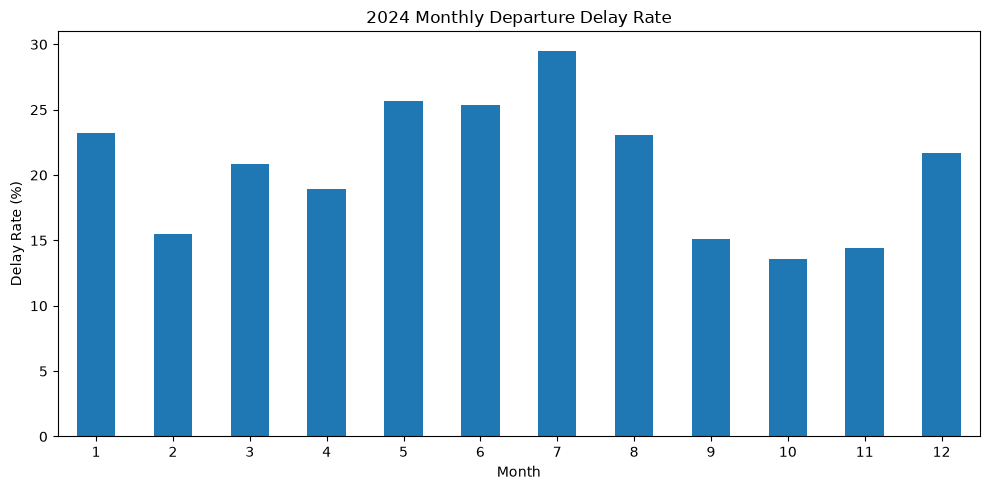

In [10]:
import matplotlib.pyplot as plt

monthly_delay_rate.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("2024 Monthly Departure Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()